In [ ]:
import torch
import math
import matplotlib.pyplot as plt
import tqdm
from scipy.stats import t

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression:
    """
    Implements Variational Inference for Student-t Process Regression
    with a Student-t Likelihood, as described in the paper.

    Args:
        X (torch.Tensor): Training inputs, shape (N, D).
        y (torch.Tensor): Training outputs, shape (N, 1).
        Z (torch.Tensor): Inducing point locations, shape (M, D).
        nu_f (float): Degrees of freedom for the TP prior.
        nu_e (float): Degrees of freedom for the Student-t likelihood.
        kernel_lengthscale (float): Lengthscale for the RBF kernel.
        kernel_variance (float): Variance (outputscale) for the RBF kernel.
        likelihood_sigma (float): Scale parameter for the likelihood.
    """
    def __init__(self, X, y, Z, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):

        self.X = X
        self.y = y
        self.Z = Z
        self.N, self.D = X.shape
        self.M = Z.shape[0]

        # Model Hyperparameters
        self.nu_f = torch.tensor(nu_f)
        self.nu_e = torch.tensor(nu_e)
        self.lengthscale = torch.tensor(kernel_lengthscale)
        self.variance = torch.tensor(kernel_variance)
        self.sigma_sq = torch.tensor(likelihood_sigma**2)

        # Pre-compute kernel matrices
        self.Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        self.Lzz = torch.linalg.cholesky(self.Kzz)
        self.Kxz = self.kernel(self.X, self.Z)
        self.Kxx_diag = torch.diag(self.kernel(self.X, self.X))

        # Variational Parameters Initialization (as per Section 6, Algorithm 1)
        # q(u) = N(m_u, S_u)
        self.m_u = torch.zeros(self.M, 1)
        # We store the cholesky of S_u for stability
        self.L_u = torch.eye(self.M)

        # q(r) = Gamma(alpha_r, beta_r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        # q(lambda_i) = Gamma(alpha_lambda_i, beta_lambda_i)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def kernel(self, A, B):
        """RBF (Squared Exponential) kernel."""
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return self.variance * torch.exp(-0.5 * sq_dist / self.lengthscale.pow(2))

    def _update_q_lambda(self):
        """
        Updates parameters for q(lambda_i) using Eq (1) and (2).
        This is the local update step.
        """
        # Eq (1): Update alpha_lambda
        # This is constant throughout the optimization
        self.alpha_lambda = self.nu_e / 2.0 + 0.5

        # Eq (2): Update beta_lambda
        # Requires calculating E_q[(y_i - f_i)^2]

        # E_q[f_i] and Var_q(f_i) from Section 5.1
        # Let's compute A = Kxz @ Kzz^{-1}
        # Kzz^{-1} m_u can be computed efficiently via cholesky solve
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, self.Lzz)
        E_q_f = self.Kxz @ Kzz_inv_mu

        # For variance, we need E_q[r^{-1}] = beta_r / (alpha_r - 1)
        E_inv_r = self.beta_r / (self.alpha_r - 1)

        # Calculate Var_q(f)
        # Var_q(f) = E[r^{-1}] * (k_ii - k_iz K_zz^{-1} k_zi) + trace(K_zz^{-1} S_u K_zz^{-1} K_zx K_xz)
        # The second term can be computed more efficiently as diag(A @ S_u @ A.T)
        A = torch.linalg.solve(self.Kzz, self.Kxz.T).T
        S_u = self.L_u @ self.L_u.T

        # Using (A L_u) * (A L_u) element-wise and summing gives the diagonal elements efficiently
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)

        # The term from the prior process variance
        var_f_prior = E_inv_r * (self.Kxx_diag - torch.sum(A * self.Kxz, dim=1))

        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        # E_q[(y_i - f_i)^2] = (y_i - E_q[f_i])^2 + Var_q(f_i) (from Section 5.1)
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        # Final update for beta_lambda
        self.beta_lambda = self.nu_e / 2.0 + (1.0 / (2.0 * self.sigma_sq)) * expected_sq_error

    def _update_q_r(self):
        """
        Updates parameters for q(r) using Eq (3) and (4).
        This is the global prior precision update.
        """
        # Eq (3): Update alpha_r
        # This is constant throughout optimization
        self.alpha_r = self.nu_f / 2.0 + self.M / 2.0

        # Eq (4): Update beta_r
        # Requires calculating E_q[u^T K_zz^{-1} u]
        # From Section 5.2: E[x^T A x] = Tr(A E[xx^T]) = Tr(A(S_u + m_u m_u^T))
        # = Tr(A S_u) + m_u^T A m_u
        S_u = self.L_u @ self.L_u.T
        Kzz_inv_Su = torch.cholesky_solve(S_u, self.Lzz)
        trace_term = torch.trace(Kzz_inv_Su)

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, self.Lzz)
        quad_form_term = self.m_u.T @ Kzz_inv_mu

        E_quad_form_u = trace_term + quad_form_term

        # Final update for beta_r
        self.beta_r = self.nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self):
        """
        Updates parameters for q(u) = N(m_u, S_u).
        This is the inducing point distribution update. See Section 4.3.
        """
        # We need E[r] and E[lambda_i] (Section 5.3)
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # The precision of q*(u) is S_u^{-1} = E[r]K_zz^{-1} + (1/sigma^2) K_zz^{-1} K_zx Diag(E[lambda]) K_xz K_zz^{-1}
        # To avoid multiple K_zz^{-1}, we find S_u directly with one M x M inversion.
        # S_u = K_zz @ [E[r]K_zz + (1/sigma^2) K_zx Diag(E[lambda]) K_xz]^{-1} @ K_zz

        # Let's compute the inner matrix to be inverted
        Psi = self.Kxz.T @ (E_lambda * self.Kxz) / self.sigma_sq
        B = E_r * self.Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        # Now compute S_u = K_zz @ B^{-1} @ K_zz
        # We solve K_zz @ (B^{-1} K_zz) = K_zz @ (L_B^T \ (L_B \ K_zz))
        Kzz_invB_Kzz = torch.cholesky_solve(self.Kzz, L_B)
        S_u = self.Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T) # Ensure symmetry

        # Update Cholesky of S_u
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        # The mean m_u = S_u @ [ (1/sigma^2) K_zz^{-1} K_zx Diag(E[lambda]) y ]
        # m_u = (1/sigma^2) S_u @ K_zz^{-1} @ K_zx @ E_lambda @ y
        # m_u = (1/sigma^2) (K_zz B^{-1} K_zz) @ K_zz^{-1} @ ...
        # m_u = (1/sigma^2) K_zz @ B^{-1} @ K_zx @ E_lambda @ y

        # We can compute B^{-1} @ (K_zx @ ...) efficiently with cholesky solve
        temp_vec = (self.Kxz.T * E_lambda.T) @ self.y / self.sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = self.Kzz @ m_u_unscaled


    def fit(self, max_iter=100, tol=1e-5):
        """
        Run the Coordinate Ascent Variational Inference (CAVI) algorithm.
        """
        print("Starting CAVI optimization...")
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            m_u_old = self.m_u.clone()

            # 1. Update local likelihood precisions q(lambda_i)
            self._update_q_lambda()

            # 2. Update global prior precision q(r)
            self._update_q_r()

            # 3. Update inducing point distribution q(u)
            self._update_q_u()

            # Check for convergence
            change = torch.norm(self.m_u - m_u_old) / torch.norm(m_u_old)
            pbar.set_description(f"Change: {change:.4e}")
            if change < tol:
                print(f"\nConverged after {i+1} iterations.")
                break
        else:
            print(f"\nReached max iterations ({max_iter}).")

    def predict(self, X_test):
        """
        Make predictions at new locations X_test.
        The predictive distribution is a univariate Student-t. (See Section 7)

        Returns:
            pred_mean (torch.Tensor): Predictive mean.
            pred_var (torch.Tensor): Predictive variance.
            pred_nu (float): Degrees of freedom of the predictive Student-t.
        """
        K_star_z = self.kernel(X_test, self.Z)
        K_star_star_diag = torch.diag(self.kernel(X_test, X_test))

        # Predictive mean (E[f*])
        # E[f*] = K_*z @ K_zz^{-1} @ m_u
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, self.Lzz)
        pred_mean = K_star_z @ Kzz_inv_mu

        # Predictive variance (Var[f*])
        # Var[f*] = Var_u[E[f*|u]] + E_u,r[Var[f*|u,r]]
        # From Section 5.1, this is:
        # K_*z K_zz^{-1} S_u K_zz^{-1} K_z* + E[r^{-1}] * (K_** - K_*z K_zz^{-1} K_z*)

        # Term 1: Variance from q(u)
        S_u = self.L_u @ self.L_u.T
        A_star = torch.linalg.solve(self.Kzz, K_star_z.T).T
        var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

        # Term 2: Variance from process prior, averaged over q(r)
        E_inv_r = self.beta_r / (self.alpha_r - 1.0)
        var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

        pred_var = var_from_prior + var_from_q_u

        # Predictive degrees of freedom is 2 * alpha_r
        pred_nu = 2 * self.alpha_r

        return pred_mean, pred_var.unsqueeze(1), pred_nu

Starting CAVI optimization...


Change: 5.8357e-06:  28%|██▊       | 14/50 [00:00<00:00, 325.90it/s]


Converged after 15 iterations.


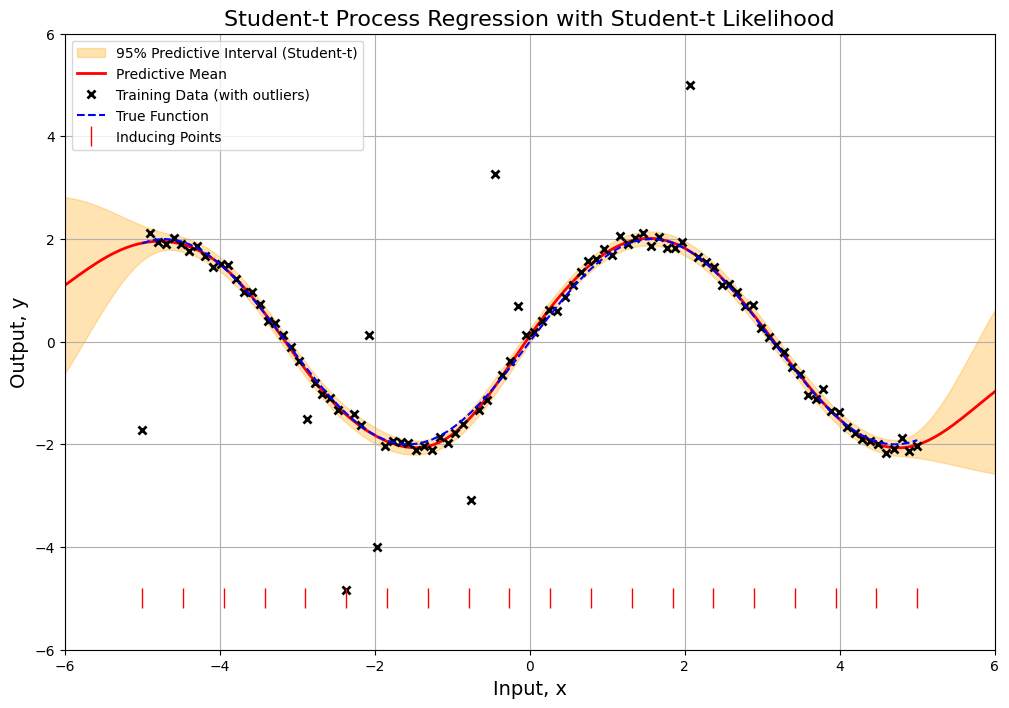

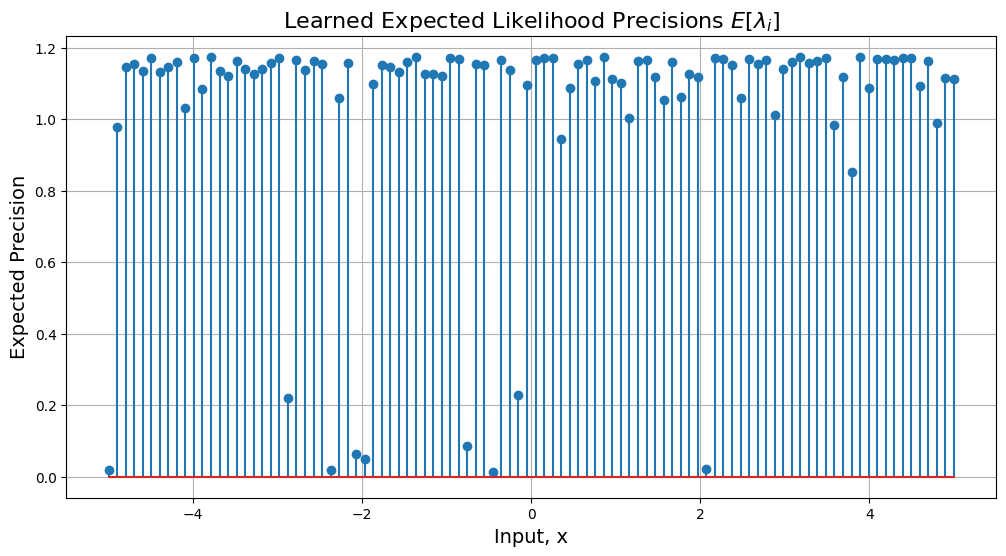

In [ ]:
if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2

    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5

    y_train = y_true + noise

    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model
    M = 20
    Z = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z=Z,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=0.2
    )

    # 3. Fit the model
    model.fit(max_iter=50, tol=1e-5)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    # === ここからが修正部分 ===

    pred_scale = torch.sqrt(pred_var)

    # SciPyのt.ppfを使って分位点を計算
    # pred_nuはTensorなので、.item()でPythonのスカラー値に変換する
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)

    # 95%信頼区間を計算
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    # === 修正部分ここまで ===

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_train, y_true, 'b--', label='True Function')
    plt.plot(model.Z, torch.zeros_like(model.Z) - 5, 'r|', ms=15, label='Inducing Points')

    plt.title('Student-t Process Regression with Student-t Likelihood', fontsize=16)
    plt.xlabel('Input, x', fontsize=14)
    plt.ylabel('Output, y', fontsize=14)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

    # Visualize the learned likelihood precisions E[lambda]
    E_lambda = model.alpha_lambda / model.beta_lambda

    plt.figure(figsize=(12, 6))
    # stemのuse_line_collection=Trueは古いmatplotlibではエラーになることがあるので削除しても良い
    plt.stem(X_train.squeeze().numpy(), E_lambda.squeeze().numpy())
    plt.title('Learned Expected Likelihood Precisions $E[\\lambda_i]$', fontsize=16)
    plt.xlabel('Input, x', fontsize=14)
    plt.ylabel('Expected Precision', fontsize=14)
    plt.grid(True)
    plt.show()

Starting optimization with hyperparameter updates...


ELBO: -299.98: 100%|██████████| 100/100 [00:01<00:00, 51.08it/s]



--- Optimized Hyperparameters ---
Kernel Lengthscale: 0.695
Kernel Variance: 2.924
Likelihood Sigma: 4.324
Prior nu_f: 61.187
Likelihood nu_e: 448.679
---------------------------------


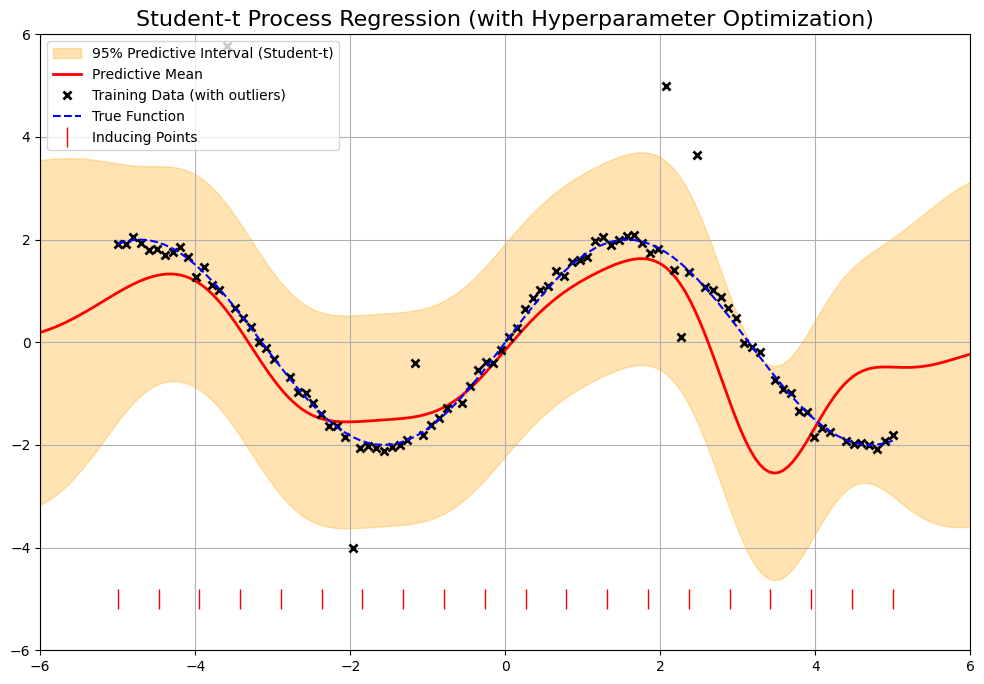

In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    """
    Implements Variational Inference for Student-t Process Regression
    with a Student-t Likelihood, now including hyperparameter optimization.
    """
    def __init__(self, X, y, Z, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__() # Important for nn.Module

        self.X = X
        self.y = y
        self.Z = Z
        self.N, self.D = X.shape
        self.M = Z.shape[0]

        # --- Hyperparameters as torch.nn.Parameter ---
        # Use softplus transform to ensure positivity for parameters that must be > 0
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters Initialization
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
        S_u = Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = Kzz @ m_u_unscaled

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # Required expectations for updates
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # CAVI updates
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        ELBO = E_log_likelihood - KL_u_r - sum(KL_lambda_i)
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        # E[log p(y|f,{lambda})]
        # Corrected this line as well to be safe
        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        # E_q[log q(u)] --- THIS IS THE FIX ---
        # Convert the constant to a tensor before taking the log
        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M

        # E_q[log q(r)]
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # E_q[log p(u|r)] --- THIS IS ALSO CORRECTED ---
        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        # E_q[log p(r)]
        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * (torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)) + \
                    (self.beta_lambda - nu_e / 2) * (self.alpha_lambda / self.beta_lambda)

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter=50, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Run optimization loop: alternate between CAVI and hyperparameter gradient steps.
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        print("Starting optimization with hyperparameter updates...")
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            # Recompute kernel matrices with current hyperparameters
            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)
            Kxz = self.kernel(self.X, self.Z)
            Kxx_diag = self.kernel(self.X, self.X).diag()

            # E-Step: Run CAVI to update variational parameters
            with torch.no_grad(): # Don't track gradients during CAVI
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters
            optimizer.zero_grad()
            # We want to MAXIMIZE the ELBO, so we minimize its negative
            neg_elbo = -self.calculate_elbo()
            neg_elbo.backward()
            optimizer.step()

            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    def predict(self, X_test):
        K_star_z = self.kernel(X_test, self.Z)
        K_star_star_diag = self.kernel(X_test, X_test).diag()
        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        pred_mean = K_star_z @ Kzz_inv_mu

        S_u = self.L_u @ self.L_u.T
        A_star = torch.linalg.solve(Kzz, K_star_z.T).T
        var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

        E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
        var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

        pred_var = var_from_prior + var_from_q_u
        _, _, _, _, nu_e = self._get_hyperparams()

        # Predictive nu is 2 * alpha_r for the function f*.
        # For the predictive distribution of y*, we could use nu_e, but
        # the paper's prediction is for f*
        pred_nu = 2 * self.alpha_r

        return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2

    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5

    y_train = y_true + noise

    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with initial hyperparameter guesses
    M = 20
    Z = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z=Z,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model (this now includes hyperparameter optimization)
    model.fit(max_iter=100, lr=0.05) # Use a higher learning rate and more iterations

    # Print optimized hyperparameters
    print("\n--- Optimized Hyperparameters ---")
    lengthscale, variance, sigma_sq, nu_f, nu_e = model._get_hyperparams()
    print(f"Kernel Lengthscale: {lengthscale.item():.3f}")
    print(f"Kernel Variance: {variance.item():.3f}")
    print(f"Likelihood Sigma: {torch.sqrt(sigma_sq).item():.3f}")
    print(f"Prior nu_f: {nu_f.item():.3f}")
    print(f"Likelihood nu_e: {nu_e.item():.3f}")
    print("---------------------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var)
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_train, y_true, 'b--', label='True Function')
    plt.plot(model.Z.detach(), torch.zeros_like(model.Z) - 5, 'r|', ms=15, label='Inducing Points')

    plt.title('Student-t Process Regression (with Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

Starting optimization with hyperparameter AND inducing point updates...


  0%|          | 0/200 [00:00<?, ?it/s]

ELBO: -90.09: 100%|██████████| 200/200 [00:01<00:00, 134.16it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-7.5509481  -7.21079134 -6.52367412 -5.7058938  -4.8267323  -3.97511324
 -3.10151027 -2.1973309  -1.33765187 -0.45433228  0.42396092  1.31321482
  2.15348931  3.08560011  3.92362264  4.84888505  5.69987542  6.517629
  7.22381179  7.55001391]
-------------------


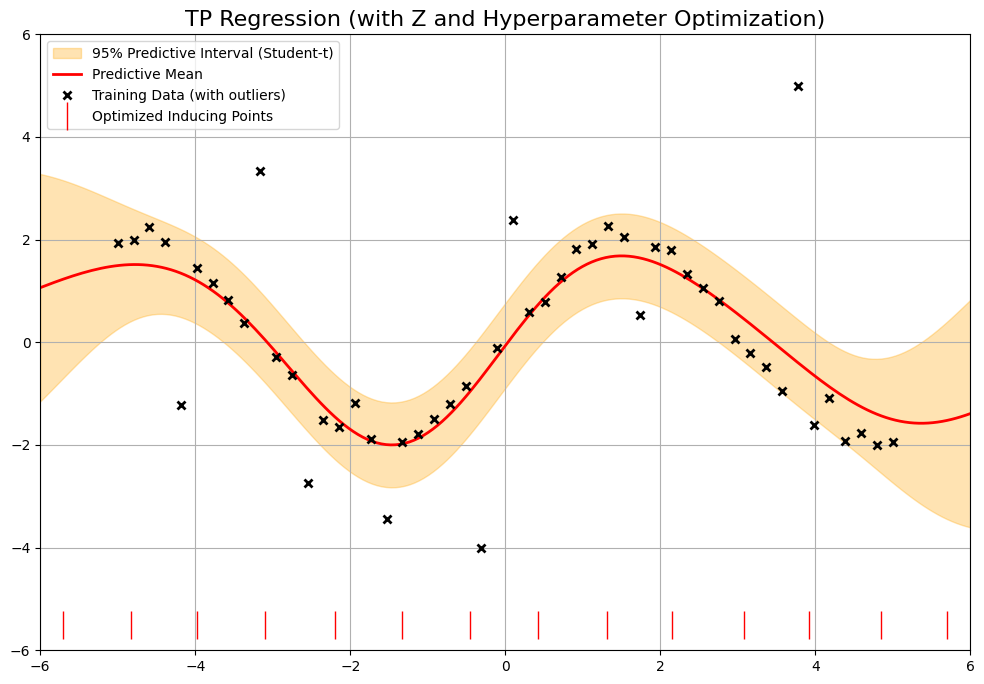

In [16]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        # Z is now a parameter to be optimized
        self.Z = nn.Parameter(Z_initial.clone())

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters (not optimized by gradient descent, so not nn.Parameter)
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    # ... (the _get_hyperparams, kernel, and CAVI update methods remain exactly the same) ...
    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
        S_u = Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = Kzz @ m_u_unscaled

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # Required expectations for updates
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # CAVI updates
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        # This method uses self.Z, self.X, so it's already compatible with Z as a parameter.
        # It's important that kernel() is called inside, as it will use the current self.Z
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * (torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)) + \
                    (self.beta_lambda - nu_e / 2) * (self.alpha_lambda / self.beta_lambda)

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter=50, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            # --- The main change is that K matrices are always recomputed ---
            # because self.Z (a parameter) is updated in every loop.
            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)
            Kxz = self.kernel(self.X, self.Z)
            Kxx_diag = self.kernel(self.X, self.X).diag()

            # E-Step: Run CAVI to update variational parameters
            with torch.no_grad():
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters and Z
            optimizer.zero_grad()
            neg_elbo = -self.calculate_elbo()
            neg_elbo.backward()
            optimizer.step()

            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    # Predict method remains the same, it will use the final optimized Z
    def predict(self, X_test):
        # We need to use .detach() on Z now before using it in the kernel for prediction,
        # as we don't want prediction to be part of the computation graph.
        Z_final = self.Z.detach()
        K_star_z = self.kernel(X_test, Z_final)
        K_star_star_diag = self.kernel(X_test, X_test).diag()
        Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        pred_mean = K_star_z @ Kzz_inv_mu

        S_u = self.L_u @ self.L_u.T
        A_star = torch.linalg.solve(Kzz, K_star_z.T).T
        var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

        E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
        var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

        pred_var = var_from_prior + var_from_q_u
        _, _, _, _, nu_e = self._get_hyperparams()
        pred_nu = 2 * self.alpha_r

        return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    N = 50
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[23] = -4.0
    y_train[43] = 5.0

    # 2. Setup the model with INITIAL inducing points
    # A common strategy is to initialize them on a subset of the data (e.g., via k-means)
    # or just uniformly as done here.
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model (this now includes Z optimization)
    model.fit(max_iter=200, lr=0.05) # May need more iterations

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # ... (prediction and plotting code remains the same) ...

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var)
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

Generating 2D toy data... 📊
Starting optimization with hyperparameter AND inducing point updates...


ELBO: -581.08: 100%|██████████| 500/500 [00:05<00:00, 88.72it/s] 


Making predictions for visualization... 🔮
Plotting the results... 🖼️


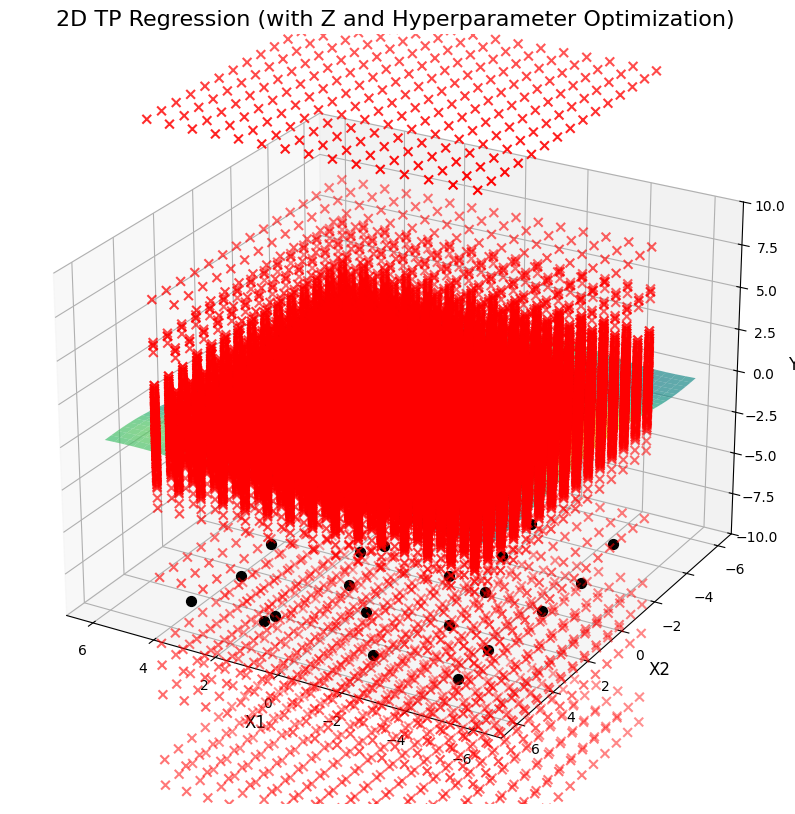

In [13]:

if __name__ == '__main__':
    # 1. Generate 2D data
    print("Generating 2D toy data... 📊")
    N_per_dim = 15
    N = N_per_dim**2
    x1 = torch.linspace(-5, 5, N_per_dim)
    x2 = torch.linspace(-5, 5, N_per_dim)
    # Create a grid of points
    X1_grid, X2_grid = torch.meshgrid(x1, x2, indexing='ij')
    X_train = torch.stack([X1_grid.flatten(), X2_grid.flatten()], dim=1)

    # A more complex 2D function
    y_true = (torch.sin(X1_grid.flatten()) * torch.cos(0.5 * X2_grid.flatten()) * 3).unsqueeze(1)

    # Add Gaussian noise and some heavy-tailed outlier noise
    noise = torch.randn(N, 1) * 0.2
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.8
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 5

    # 2. Setup the model with INITIAL 2D inducing points
    M_per_dim = 5
    M = M_per_dim**2
    z1 = torch.linspace(-5, 5, M_per_dim)
    z2 = torch.linspace(-5, 5, M_per_dim)
    Z1_grid_init, Z2_grid_init = torch.meshgrid(z1, z2, indexing='ij')
    Z_initial = torch.stack([Z1_grid_init.flatten(), Z2_grid_init.flatten()], dim=1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=1.0, # This will be optimized
        kernel_variance=2.0,   # This will be optimized
        likelihood_sigma=0.5   # This will be optimized
    )

    # 3. Fit the model
    model.fit(max_iter=500, lr=0.05)

    # 4. Make predictions on a finer grid for plotting
    print("Making predictions for visualization... 🔮")
    test_dim = 40
    x1_test = torch.linspace(-6, 6, test_dim)
    x2_test = torch.linspace(-6, 6, test_dim)
    X1_test_grid, X2_test_grid = torch.meshgrid(x1_test, x2_test, indexing='ij')
    X_test = torch.stack([X1_test_grid.flatten(), X2_test_grid.flatten()], dim=1)

    pred_mean, _, _ = model.predict(X_test)
    pred_mean_grid = pred_mean.reshape(test_dim, test_dim)

    # 5. Visualize the results in 3D
    print("Plotting the results... 🖼️")
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the predictive surface
    ax.plot_surface(X1_test_grid.numpy(), X2_test_grid.numpy(), pred_mean_grid.numpy(),
                    cmap='viridis', alpha=0.7, label='Predictive Mean Surface')

    # Plot the training data points
    ax.scatter(X_train[:, 0].numpy(), X_train[:, 1].numpy(), y_train.numpy(),
               c='red', marker='x', s=40, label='Training Data (with outliers)')

    # Plot the final optimized inducing points on the xy-plane
    Z_final = model.Z.detach()
    ax.scatter(Z_final[:, 0].numpy(), Z_final[:, 1].numpy(), -10, # Plot at a low z-value
               c='black', marker='o', s=50, depthshade=False, label='Optimized Inducing Points')

    ax.set_title('2D TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    ax.set_xlabel('X1', fontsize=12)
    ax.set_ylabel('X2', fontsize=12)
    ax.set_zlabel('Y', fontsize=12)
    ax.set_zlim(-10, 10)
    ax.view_init(elev=25., azim=120) # Adjust view angle for better perspective
    # Note: Adding a direct legend to 3D surface plots is tricky in Matplotlib.
    # The labels in the scatter calls serve for clarity in the code.
    plt.show()


In [7]:
X_train.shape, y_train.shape, pred_mean.shape

(torch.Size([225, 2]), torch.Size([225, 1]), torch.Size([1600, 1]))

Starting optimization with hyperparameter AND inducing point updates...


ELBO: -62.65:   3%|▎         | 3/100 [00:00<00:03, 27.36it/s]

ELBO: -132.11: 100%|██████████| 100/100 [00:04<00:00, 22.77it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-6.24949515 -4.64457344 -4.34150606 -4.08124671 -3.16634024 -1.84849844
 -1.65672545 -1.31631914 -0.69099494  0.34900328  0.82707859  1.63616109
  2.13137536  2.77740775  3.62793675  4.53129678  4.93817804  6.34353934
  6.73870176  7.12966319]
-------------------


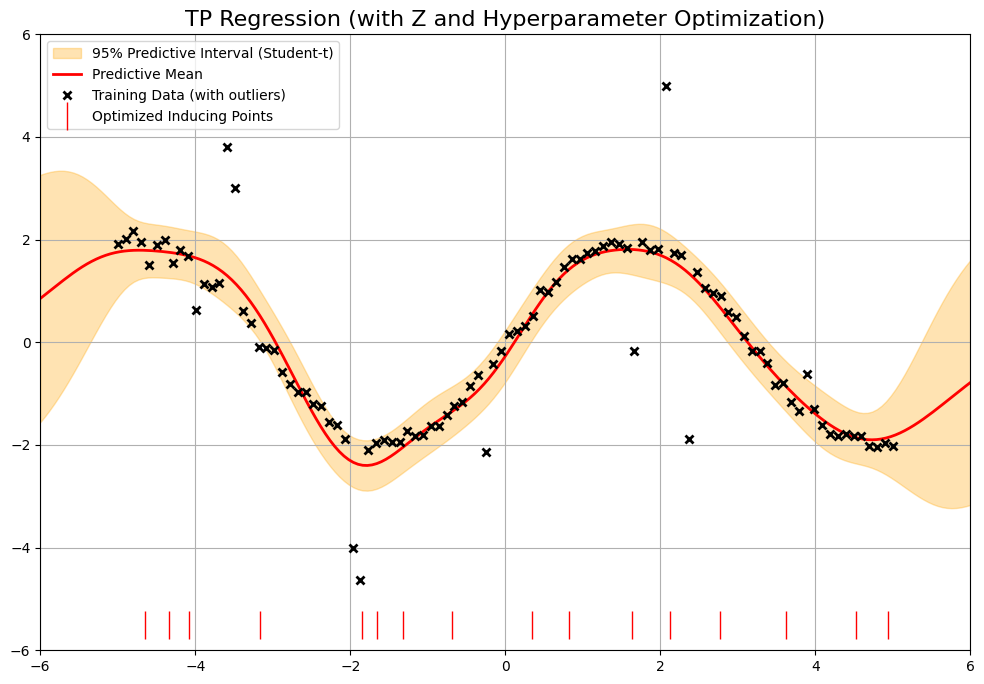

In [4]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        # Z is now a parameter to be optimized
        self.Z = nn.Parameter(Z_initial.clone())

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters (not optimized by gradient descent, so not nn.Parameter)
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    # ... (the _get_hyperparams, kernel, and CAVI update methods remain exactly the same) ...
    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
        S_u = Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T)
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = Kzz @ m_u_unscaled

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # Required expectations for updates
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # CAVI updates
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        # This method uses self.Z, self.X, so it's already compatible with Z as a parameter.
        # It's important that kernel() is called inside, as it will use the current self.Z
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * (torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)) + \
                    (self.beta_lambda - nu_e / 2) * (self.alpha_lambda / self.beta_lambda)

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    # def fit(self, max_iter=50, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
    #     optimizer = torch.optim.Adam(self.parameters(), lr=lr)

    #     print("Starting optimization with hyperparameter AND inducing point updates...")
    #     pbar = tqdm.trange(max_iter)
    #     for i in pbar:
    #         # --- The main change is that K matrices are always recomputed ---
    #         # because self.Z (a parameter) is updated in every loop.
    #         Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
    #         Lzz = torch.linalg.cholesky(Kzz)
    #         Kxz = self.kernel(self.X, self.Z)
    #         Kxx_diag = self.kernel(self.X, self.X).diag()

    #         # E-Step: Run CAVI to update variational parameters
    #         with torch.no_grad():
    #             self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

    #         # M-Step: Update hyperparameters and Z
    #         optimizer.zero_grad()
    #         neg_elbo = -self.calculate_elbo()
    #         neg_elbo.backward()
    #         optimizer.step()

    #         pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    def fit(self, max_iter_global=50, max_iter_local=50, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):

        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter_global)
        for i in pbar:
            # --- The main change is that K matrices are always recomputed ---
            # because self.Z (a parameter) is updated in every loop.
            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)
            Kxz = self.kernel(self.X, self.Z)
            Kxx_diag = self.kernel(self.X, self.X).diag()

            # E-Step: Run CAVI to update variational parameters
            with torch.no_grad():
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            # M-Step: Update hyperparameters and Z
            optimizer = torch.optim.Adam(self.parameters(), lr=lr)

            for j in range(max_iter_local):

                optimizer.zero_grad()
                neg_elbo = -self.calculate_elbo()
                neg_elbo.backward()
                optimizer.step()

            pbar.set_description(f"ELBO: {-neg_elbo.item():.2f}")

    # Predict method remains the same, it will use the final optimized Z
    def predict(self, X_test):
        # We need to use .detach() on Z now before using it in the kernel for prediction,
        # as we don't want prediction to be part of the computation graph.
        Z_final = self.Z.detach()
        K_star_z = self.kernel(X_test, Z_final)
        K_star_star_diag = self.kernel(X_test, X_test).diag()
        Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        pred_mean = K_star_z @ Kzz_inv_mu

        S_u = self.L_u @ self.L_u.T
        A_star = torch.linalg.solve(Kzz, K_star_z.T).T
        var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

        E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
        var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

        pred_var = var_from_prior + var_from_q_u
        _, _, _, _, nu_e = self._get_hyperparams()
        pred_nu = 2 * self.alpha_r

        return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    # A common strategy is to initialize them on a subset of the data (e.g., via k-means)
    # or just uniformly as done here.
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model (this now includes Z optimization)
    model.fit(max_iter_global=100, max_iter_local=10, lr=0.05) # May need more iterations

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # ... (prediction and plotting code remains the same) ...

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var)
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

# SCAVI

Starting SVI optimization...


Epoch 150/150 | Stochastic ELBO: 1837.15: 100%|██████████| 150/150 [00:06<00:00, 22.67it/s]



--- Optimized Z ---
[-4.96887976 -4.29982074 -3.61461211 -3.19741752 -3.11756905 -2.58732129
 -1.93200101 -1.21180883 -0.54420525 -0.12082123  0.16546299  0.6422016
  1.3164197   2.07338247  2.69203508  3.13701922  3.21306713  3.76619927
  4.41154398  5.03232886]
-------------------


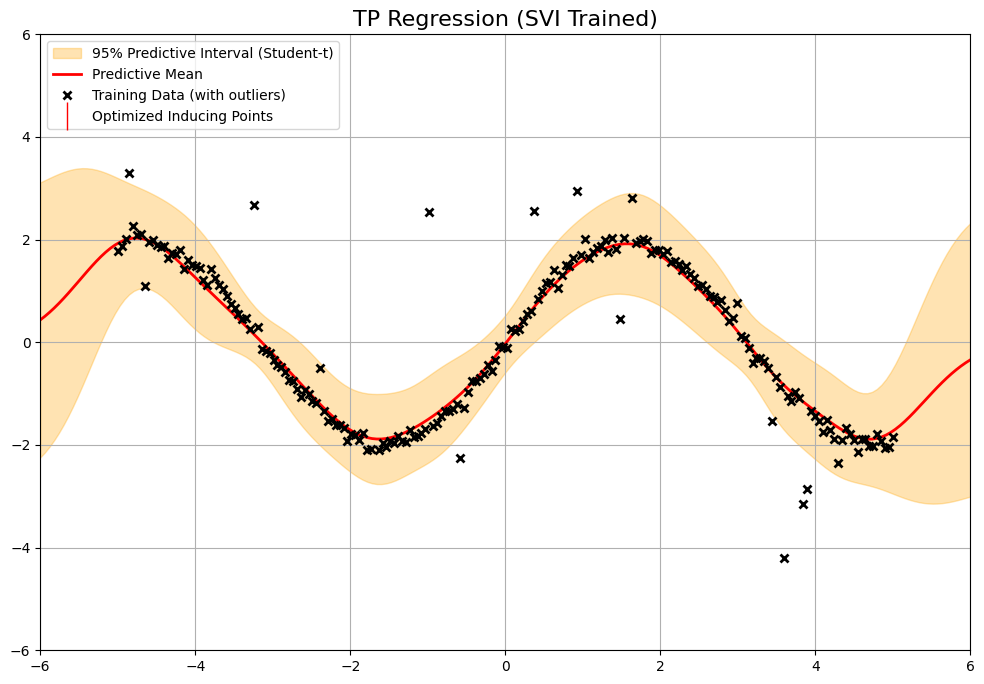

In [11]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm
from torch.utils.data import TensorDataset, DataLoader

# デフォルトのテンソル型を設定
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # データ（バッファとして登録）
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- ハイパーパラメータと誘導点をnn.Parameterとして登録 ---
        self.Z = nn.Parameter(Z_initial.clone())
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- 変分パラメータ（手動で更新するためnn.Parameterではない） ---
        self.m_u = torch.zeros(self.M, 1)
        # S_u = L_u @ L_u.T
        self.S_u = torch.eye(self.M)
        
        # グローバルパラメータ q(r)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        
        # ローカルパラメータ q(lambda_i) - 全データ分を初期化
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """log変換されたパラメータから正のハイパーパラメータを取得"""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))
    
    ##############################################################
    ### SVI (Stochastic Variational Inference)用の新メソッド ###
    ##############################################################

    def fit_svi(self, epochs=100, batch_size=64, lr=0.01, rho_decay_rate=0.7):
        """
        確率的変分推論（SVI）を用いてモデルを学習させる。
        """
        print("Starting SVI optimization...")
        
        # 1. DataLoaderの準備
        dataset = TensorDataset(self.X, self.y, torch.arange(self.N))
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        # 2. ハイパーパラメータと誘導点Z用のオプティマイザ
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        
        global_step = 0
        pbar = tqdm.trange(epochs)
        
        for epoch in pbar:
            for x_batch, y_batch, batch_indices in dataloader:
                global_step += 1
                
                # 3. ステップサイズ（学習率）の決定
                # Polyak平均化のためのステップサイズ。徐々に減衰させる。
                step_size = (global_step + 10)**-rho_decay_rate

                # 4. Eステップ：変分パラメータの確率的更新
                # with torch.no_grad() は勾配計算を無効にし、手動更新の計算を高速化
                with torch.no_grad():
                    self._svi_e_step(x_batch, y_batch, batch_indices, step_size)

                # 5. Mステップ：ハイパーパラメータとZの更新
                optimizer.zero_grad()
                # 確率的ELBOを計算
                neg_stochastic_elbo = -self._calculate_stochastic_elbo(x_batch, y_batch, batch_indices)
                # 勾配を計算
                neg_stochastic_elbo.backward()
                # パラメータを更新
                optimizer.step()

                pbar.set_description(f"Epoch {epoch+1}/{epochs} | Stochastic ELBO: {-neg_stochastic_elbo.item():.2f}")

    def _svi_e_step(self, x_batch, y_batch, batch_indices, step_size):
        """
        SVIのEステップ。ミニバッチで変分パラメータを更新する。
        """
        # --- 共通計算 ---
        # detach()でZの現在の値を取得（このステップではZ自体の勾配は不要）
        Kzz = self.kernel(self.Z.detach(), self.Z.detach()) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(x_batch, self.Z.detach())

        # --- 1. ローカルパラメータ q(lambda_i) の更新 ---
        # E_q[f] と Var_q[f] をミニバッチに対して計算
        E_q_f_batch, Var_q_f_batch = self._calculate_f_expectations(Kzz, Lzz, Kxz_batch, x_batch)
        
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        
        # ミニバッチに対応する部分だけを更新
        alpha_lambda_target = nu_e / 2.0 + 0.5
        expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
        beta_lambda_target = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error
        
        self.alpha_lambda[batch_indices] = alpha_lambda_target
        self.beta_lambda[batch_indices] = beta_lambda_target
        
        # --- 2. グローバルパラメータ q(u) の更新 ---
        E_r = self.alpha_r / self.beta_r
        E_lambda_batch = self.alpha_lambda[batch_indices] / self.beta_lambda[batch_indices]
        
        # ミニバッチからターゲットとなる S_u と m_u を計算
        Psi_batch = Kxz_batch.T @ (E_lambda_batch * Kxz_batch)
        
        # 全データにスケールアップ
        scaled_Psi = (self.N / len(x_batch)) * Psi_batch

        S_u_inv_target = E_r * torch.inverse(Kzz) + scaled_Psi / sigma_sq
        S_u_target = torch.inverse(S_u_inv_target)
        S_u_target = 0.5 * (S_u_target + S_u_target.T) # 数値的安定性のため

        temp_vec_batch = (Kxz_batch.T * E_lambda_batch.T) @ y_batch
        scaled_temp_vec = (self.N / len(x_batch)) * temp_vec_batch
        m_u_target = (S_u_target @ scaled_temp_vec) / sigma_sq

        # Polyak平均化で更新
        self.S_u = (1 - step_size) * self.S_u + step_size * S_u_target
        self.m_u = (1 - step_size) * self.m_u + step_size * m_u_target
        
        # --- 3. グローバルパラメータ q(r) の更新 ---
        Kzz_inv_Su = torch.cholesky_solve(self.S_u, Lzz)
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(Kzz_inv_Su) + self.m_u.T @ Kzz_inv_mu

        _, _, _, nu_f, _ = self._get_hyperparams()
        alpha_r_target = nu_f / 2.0 + self.M / 2.0
        beta_r_target = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()
        
        # Polyak平均化で更新
        self.alpha_r = (1 - step_size) * self.alpha_r + step_size * alpha_r_target
        self.beta_r = (1 - step_size) * self.beta_r + step_size * beta_r_target
        
    def _calculate_stochastic_elbo(self, x_batch, y_batch, batch_indices):
        """
        ミニバッチを用いてELBOの不偏推定量を計算する。
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(x_batch, self.Z)
        
        # --- 1. 期待対数尤度 (ミニバッチで計算) ---
        E_q_f_batch, Var_q_f_batch = self._calculate_f_expectations(Kzz, Lzz, Kxz_batch, x_batch)
        
        E_lambda_batch = self.alpha_lambda[batch_indices] / self.beta_lambda[batch_indices]
        E_log_lambda_batch = torch.digamma(self.alpha_lambda[batch_indices]) - torch.log(self.beta_lambda[batch_indices])
        
        expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
        
        # バッチに対する対数尤度
        e_log_lik_batch = -0.5 * len(x_batch) * torch.log(torch.tensor(2 * torch.pi)) \
                        - 0.5 * len(x_batch) * torch.log(sigma_sq) \
                        + 0.5 * torch.sum(E_log_lambda_batch) \
                        - 0.5 / sigma_sq * torch.sum(E_lambda_batch * expected_sq_error)

        # --- 2. KLダイバージェンス for u and r (グローバルなので全体を計算) ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        
        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(self.S_u)[1] - 0.5 * self.M
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        # cholesky_solveの引数を修正
        Kzz_inv_Su = torch.cholesky_solve(self.S_u, Lzz)
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_quad_form_u = torch.trace(Kzz_inv_Su) + self.m_u.T @ Kzz_inv_mu
        
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(Kzz)[1] + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KLダイバージェンス for lambda (ミニバッチで計算) ---
        kl_lambda_batch = torch.lgamma(self.alpha_lambda[batch_indices]) - self.alpha_lambda[batch_indices] * torch.log(self.beta_lambda[batch_indices]) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda[batch_indices] - nu_e / 2) * (torch.digamma(self.alpha_lambda[batch_indices]) - torch.log(self.beta_lambda[batch_indices])) + \
                    (self.beta_lambda[batch_indices] - nu_e / 2) * (self.alpha_lambda[batch_indices] / self.beta_lambda[batch_indices])
        kl_lambda_batch_sum = torch.sum(kl_lambda_batch)

        # --- 4. 最終的な確率的ELBO ---
        # データ依存項をスケールアップして不偏推定量にする
        scaling_factor = self.N / len(x_batch)
        stochastic_elbo = scaling_factor * (e_log_lik_batch - kl_lambda_batch_sum) - kl_u_r
        
        return stochastic_elbo

    def _calculate_f_expectations(self, Kzz, Lzz, Kxz, X_in):
        """
        与えられた入力X_inに対する E[f] と Var[f] を計算するヘルパー関数
        """
        # E_q[f] = Kxz Kzz^{-1} m_u
        # cholesky_solveの引数を修正
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu
        
        # Var_q[f]
        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r
        
        K_in_in_diag = self.kernel(X_in, X_in).diag()
        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ torch.linalg.cholesky(self.S_u))**2, dim=1)
        var_f_prior = E_inv_r * (K_in_in_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)
        
        return E_q_f, Var_q_f

    def predict(self, X_test):
        # 予測時には学習済みの最終パラメータを使う
        Z_final = self.Z.detach()
        K_star_z = self.kernel(X_test, Z_final)
        K_star_star_diag = self.kernel(X_test, X_test).diag()
        Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)

        # cholesky_solveの引数を修正
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        pred_mean = K_star_z @ Kzz_inv_mu

        A_star = torch.linalg.solve(Kzz, K_star_z.T).T
        
        L_u = torch.linalg.cholesky(self.S_u + torch.eye(self.M)*1e-6) # S_uからL_uを復元
        var_from_q_u = torch.sum((A_star @ L_u)**2, dim=1)

        E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
        var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

        pred_var = var_from_prior + var_from_q_u
        # 予測分布の自由度はν_fに対応
        pred_nu = 2 * self.alpha_r 

        return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()


if __name__ == '__main__':
    # 1. データ生成
    N = 200 # データ数を増やす
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    # 外れ値を生成
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:int(N*0.1)] # 10%を外れ値に
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    
    # 2. モデルのセットアップ
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=2.1,
        nu_e=2.1,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. SVIでモデルを学習
    model.fit_svi(epochs=150, batch_size=32, lr=0.01, rho_decay_rate=0.6)

    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")
    
    # 4. 予測
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. 結果の可視化
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var)
    df = pred_nu.item()
    # 自由度が非常に小さい場合のエラーハンドリング
    if df > 0:
        lower_quantile = t.ppf(0.025, df=df)
        upper_quantile = t.ppf(0.975, df=df)
        lower = pred_mean + lower_quantile * pred_scale
        upper = pred_mean + upper_quantile * pred_scale
        plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')

    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), plt.ylim()[0] + 0.1), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('TP Regression (SVI Trained)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.show()

Starting SVI optimization for non-sparse model...


Epoch 6/500 | Stochastic ELBO: 142.67:   0%|          | 0/500 [00:00<?, ?it/s] 

Epoch 500/500 | Stochastic ELBO: -146.98: 100%|██████████| 500/500 [00:10<00:00, 48.01it/s]


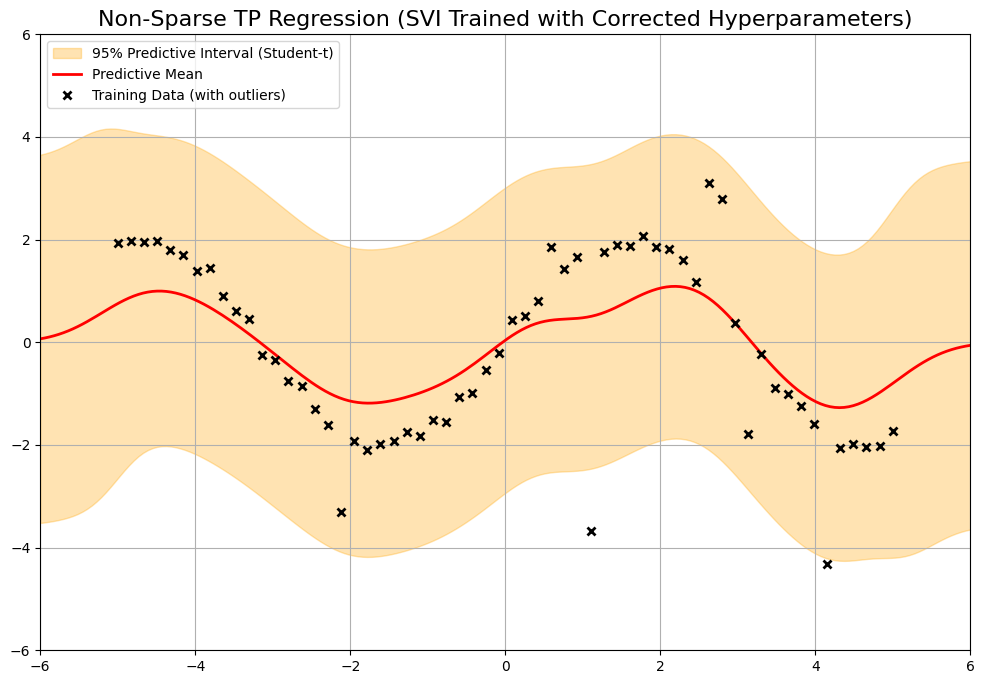

In [11]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm
from torch.utils.data import TensorDataset, DataLoader

# デフォルトのテンソル型を設定
torch.set_default_dtype(torch.float64)

class NonSparseTPRegression(nn.Module):
    """
    Implements the full (non-sparse) Student-t Process regression model.
    This class includes both a CAVI and an SVI implementation for comparison.
    """
    def __init__(self, X, y, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape

        # --- Hyperparameters ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Variational Parameters ---
        self.m_f = torch.zeros(self.N, 1)
        self.S_f = torch.eye(self.N)

        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)

        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))
        
    ##########################################################################
    ### SVI (Stochastic Variational Inference) for Non-Sparse Model ###
    ##########################################################################
    def fit_svi(self, epochs=100, batch_size=16, lr=0.01, rho_decay_rate=0.7):
        """
        Fits the non-sparse model using Stochastic Variational Inference (SVI).
        Note: This is computationally expensive and mainly for educational purposes.
        """
        print("Starting SVI optimization for non-sparse model...")
        
        dataset = TensorDataset(self.X, self.y, torch.arange(self.N))
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        
        global_step = 0
        pbar = tqdm.trange(epochs)
        
        for epoch in pbar:
            for x_batch, y_batch, batch_indices in dataloader:
                global_step += 1
                step_size = (global_step + 20)**-rho_decay_rate

                # --- E-Step: 変分パラメータの確率的更新 ---
                # このステップでは勾配は不要なので、計算グラフから切り離した（detachした）Kxxを使う
                with torch.no_grad():
                    Kxx_no_grad = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                    Lxx_no_grad = torch.linalg.cholesky(Kxx_no_grad)
                    self._svi_e_step(y_batch, batch_indices, Lxx_no_grad, step_size)

                # --- M-Step: ハイパーパラメータとZの更新 ---
                optimizer.zero_grad()
                
                # 修正箇所：KxxとLxxをミニバッチループの内側で再計算
                # これにより、backward()ごとに新しい計算グラフが作成される
                Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
                Lxx = torch.linalg.cholesky(Kxx)
                
                neg_stochastic_elbo = -self._calculate_stochastic_elbo(y_batch, batch_indices, Lxx)
                neg_stochastic_elbo.backward()
                optimizer.step()

                pbar.set_description(f"Epoch {epoch+1}/{epochs} | Stochastic ELBO: {-neg_stochastic_elbo.item():.2f}")

    def _svi_e_step(self, y_batch, batch_indices, Lxx, step_size):
        """
        Performs a single SVI E-step update for the non-sparse model.
        """
        # --- 1. ローカルパラメータ q(lambda_i) の更新 ---
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        
        Var_q_f_batch = self.S_f.diag()[batch_indices].unsqueeze(1)
        E_q_f_batch = self.m_f[batch_indices]

        alpha_lambda_target = nu_e / 2.0 + 0.5
        expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
        beta_lambda_target = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error
        
        self.alpha_lambda[batch_indices] = alpha_lambda_target
        self.beta_lambda[batch_indices] = beta_lambda_target
        
        # --- 2. グローバルパラメータ q(f) の更新 ---
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        # ミニバッチ情報からターゲットを計算
        # diag(E[lambda])のミニバッチ版を作成
        diag_E_lambda_S = torch.zeros(self.N)
        diag_E_lambda_S[batch_indices.squeeze()] = E_lambda[batch_indices].squeeze()
        Lambda_S = torch.diag(diag_E_lambda_S)

        Kxx_inv = torch.cholesky_inverse(Lxx)
        
        # ターゲットパラメータの計算
        S_f_inv_target = E_r * Kxx_inv + (self.N / len(batch_indices)) * (1.0 / sigma_sq) * Lambda_S
        S_f_target = torch.inverse(S_f_inv_target)
        S_f_target = 0.5 * (S_f_target + S_f_target.T)

        m_f_target = S_f_target @ ((self.N / len(batch_indices)) * (1.0 / sigma_sq) * (Lambda_S @ self.y))
        
        # Polyak平均化で更新
        self.S_f = (1 - step_size) * self.S_f + step_size * S_f_target
        self.m_f = (1 - step_size) * self.m_f + step_size * m_f_target

        # --- 3. グローバルパラメータ q(r) の更新 ---
        Kxx_inv_Sf = Kxx_inv @ self.S_f
        trace_term = torch.trace(Kxx_inv_Sf)
        Kxx_inv_mf = Kxx_inv @ self.m_f
        quad_form_term = self.m_f.T @ Kxx_inv_mf
        E_quad_form_f = trace_term + quad_form_term
        
        _, _, _, nu_f, _ = self._get_hyperparams()
        alpha_r_target = nu_f / 2.0 + self.N / 2.0
        beta_r_target = nu_f / 2.0 + 0.5 * E_quad_form_f.squeeze()

        self.alpha_r = (1 - step_size) * self.alpha_r + step_size * alpha_r_target
        self.beta_r = (1 - step_size) * self.beta_r + step_size * beta_r_target


    def _calculate_stochastic_elbo(self, y_batch, batch_indices, Lxx):
        """
        Calculates the stochastic ELBO for the non-sparse model.
        """
        _, _, sigma_sq, nu_f, nu_e = self._get_hyperparams()
        
        batch_size = len(y_batch)
        scaling_factor = self.N / batch_size

        # --- 1. Expected Log Likelihood (Stochastic) ---
        E_q_f_batch = self.m_f[batch_indices]
        Var_q_f_batch = self.S_f.diag()[batch_indices].unsqueeze(1)
        expected_sq_error = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch

        E_lambda_batch = self.alpha_lambda[batch_indices] / self.beta_lambda[batch_indices]
        E_log_lambda_batch = torch.digamma(self.alpha_lambda[batch_indices]) - torch.log(self.beta_lambda[batch_indices])

        e_log_lik_batch = -0.5 * batch_size * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * batch_size * torch.log(sigma_sq) + \
                          0.5 * torch.sum(E_log_lambda_batch) - \
                          0.5 / sigma_sq * torch.sum(E_lambda_batch * expected_sq_error)

        # --- 2. KL(q(f)q(r) || p(f,r)) (Global) ---
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_f = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * torch.slogdet(self.S_f)[1] - 0.5 * self.N
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        Kxx_inv = torch.cholesky_inverse(Lxx)
        E_quad_form_f = torch.trace(Kxx_inv @ self.S_f) + self.m_f.T @ (Kxx_inv @ self.m_f)
        
        log_det_Kxx = 2 * torch.sum(torch.log(torch.diag(Lxx)))
        E_log_p_f_r = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kxx + \
                      0.5 * self.N * E_log_r - 0.5 * E_r * E_quad_form_f
        E_log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                    (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_f_r = log_q_f + log_q_r - E_log_p_f_r - E_log_p_r

        # --- 3. KL(q(lambda) || p(lambda)) (Stochastic) ---
        kl_lambda_batch = torch.lgamma(self.alpha_lambda[batch_indices]) - self.alpha_lambda[batch_indices] * torch.log(self.beta_lambda[batch_indices]) - \
                          (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                          (self.alpha_lambda[batch_indices] - nu_e / 2) * E_log_lambda_batch + \
                          (self.beta_lambda[batch_indices] - nu_e / 2) * E_lambda_batch
        kl_lambda_sum_batch = torch.sum(kl_lambda_batch)

        # --- Final Stochastic ELBO ---
        elbo = scaling_factor * (e_log_lik_batch - kl_lambda_sum_batch) - kl_f_r
        return elbo

    def predict(self, X_test):
        with torch.no_grad():
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kxx = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            Lxx = torch.linalg.cholesky(Kxx)

            Kxx_inv_mf = torch.cholesky_solve(self.m_f, Lxx)
            pred_mean = K_star_x @ Kxx_inv_mf

            Kxx_inv_k_x_star = torch.cholesky_solve(K_star_x.T, Lxx)
            
            var_from_q_f = (K_star_x @ (torch.cholesky_solve(self.S_f @ Kxx_inv_k_x_star, Lxx))).diag()

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - (K_star_x * Kxx_inv_k_x_star.T).sum(dim=1))
            
            pred_var = var_from_prior + var_from_q_f
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()

if __name__ == '__main__':
    # 1. データ生成 (変更なし)
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:8]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    
    # 2. Non-sparseモデルのセットアップ
    model = NonSparseTPRegression(
        X=X_train,
        y=y_train,
        nu_f=10.0,  # 少し安定させるために初期値を変更
        nu_e=2.0,  # 少し安定させるために初期値を変更
        kernel_lengthscale=1.0, # 初期値はデータスケールに合わせる
        kernel_variance=1.0,
        # ★★★ 最も重要な変更点 ★★★
        # likelihood_sigma の初期値を、データスケールに対して現実的な値に変更
        likelihood_sigma=0.3
    )

    # 3. SVIでモデルを学習
    # ★ 学習率を下げ、エポック数を増やして安定性を向上
    model.fit_svi(epochs=500, batch_size=16, lr=0.01, rho_decay_rate=0.7)

    # 4. 予測 (変更なし)
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. 結果の可視化 (変更なし)
    plt.figure(figsize=(12, 8))
    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    if df > 0:
        lower_quantile = t.ppf(0.025, df=df)
        upper_quantile = t.ppf(0.975, df=df)
        lower = pred_mean + lower_quantile * pred_scale
        upper = pred_mean + upper_quantile * pred_scale
        plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    plt.title('Non-Sparse TP Regression (SVI Trained with Corrected Hyperparameters)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    plt.show()